{'phases': [array([66.  , 60.  ,  0.53, 37.  ]), array([66.  , 60.  ,  0.53, 26.  ])], 'num_clsutered_grains': 7, 'radius': 12.0, 'clustered_center': array([[  0.,  87.],
       [ 66., 174.],
       [132.,  88.],
       [198., 337.],
       [264., 165.],
       [330.,  25.],
       [396., 333.]])}
torch.Size([400, 512, 1])
tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 

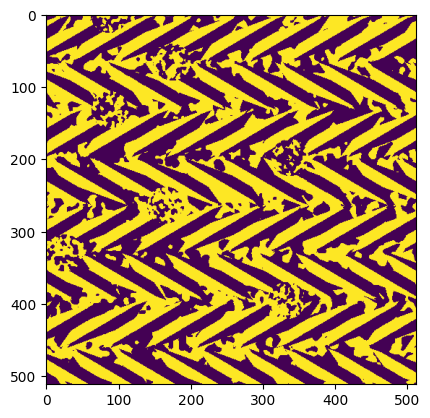

In [6]:
%reload_ext autoreload
%autoreload 2

from torch.utils.data import Dataset, DataLoader, default_collate, random_split
from torchvision import transforms as T
from PIL import Image
from pathlib import Path
import torch
import matplotlib.pyplot as plt
import numpy as np

from data.AM_dataset import MultiPhaseDataset, RowDataset, row_collate_fn

def exists(x):
    return x is not None

#data_path = '/mnt/data/yiwang/code/RandomMaterial/clustered_grain/massive_03_different_noise_levels_with_cluster'
data_path = '/mnt/data/yiwang/code/RandomMaterial/clustered_grain/massive_05_testify_bilevel_sampling_2phases_with_clustered_grains'
material_dataset = MultiPhaseDataset(data_path, [512,512], n_phases=2)
row_dataset = RowDataset(material_dataset, rows_per_image=400)
img , label = material_dataset[0]
print(label)
plt.imshow(img.detach().numpy().squeeze())
row_loader = DataLoader(row_dataset, batch_size=400, shuffle=False, collate_fn=row_collate_fn)
for each in row_loader:
    x, l = each
    print(x.shape)
    print(l)
    break

-1.0 1.0


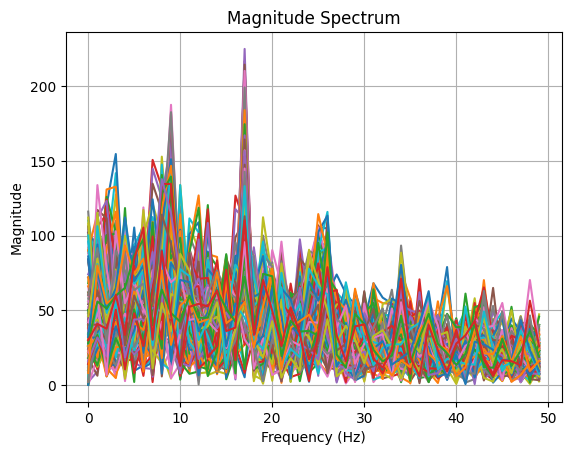

In [7]:
np_arr = img.squeeze().detach().numpy()
print(np_arr.min(), np_arr.max())

plt.figure()
rows, labels = next(iter(row_loader))
for idx in range(len(labels)):
    if labels[idx]==1:

        # Compute the FFT
        t = torch.linspace(0, 1, 100)
        fft_result = torch.fft.fft(rows[idx, :, 0])
        freqs = torch.fft.fftfreq(len(t), 1./100) #1/1000
        
        # Take only the positive frequencies
        positive_freqs = freqs[:len(freqs)//2]
        magnitude = torch.abs(fft_result)[:len(freqs)//2]

        # Plot the magnitude spectrum
        plt.plot(positive_freqs, magnitude)
plt.title("Magnitude Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.grid(True)
plt.show()    

# for row_index in [30, 100, 150, 450, 400]:
#     plt.figure()
#      # Compute the FFT
#     t = np.linspace(0, 1, 100, endpoint=False)
#     fft_result = np.fft.fft(np_arr[row_index, :])
#     freqs = np.fft.fftfreq(len(t), 1./100) #1/1000
    
#     # Take only the positive frequencies
#     positive_freqs = freqs[:len(freqs)//2]
#     magnitude = np.abs(fft_result)[:len(freqs)//2]

#     # Plot the magnitude spectrum
#     plt.plot(positive_freqs, magnitude)
#     plt.title("Magnitude Spectrum")
#     plt.xlabel("Frequency (Hz)")
#     plt.ylabel("Magnitude")
#     plt.grid(True)
#     plt.show()

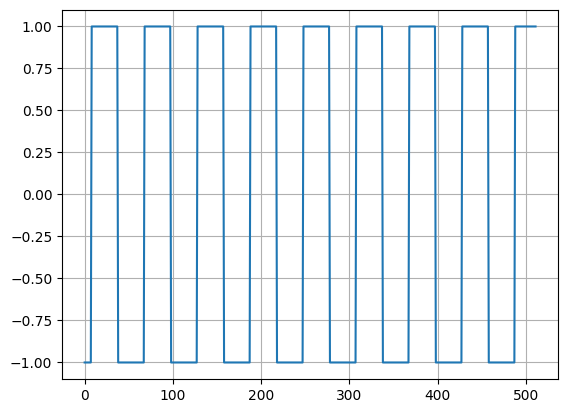

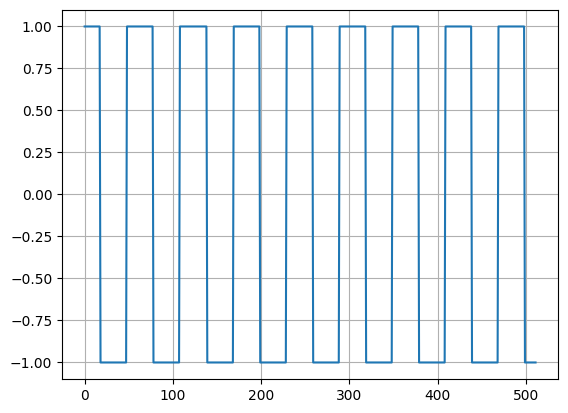

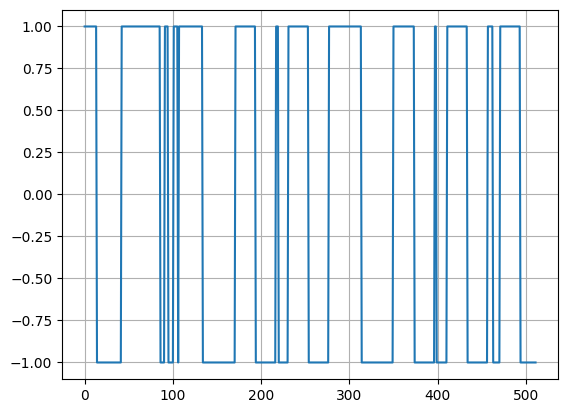

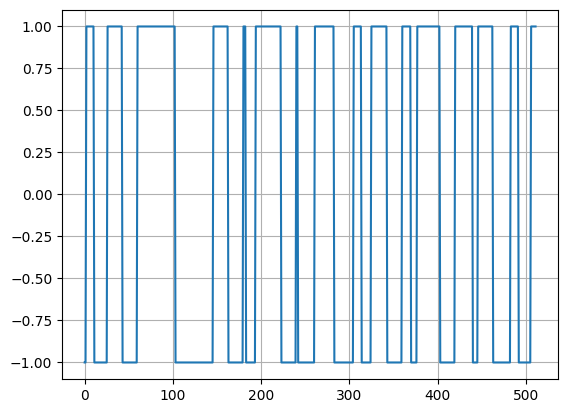

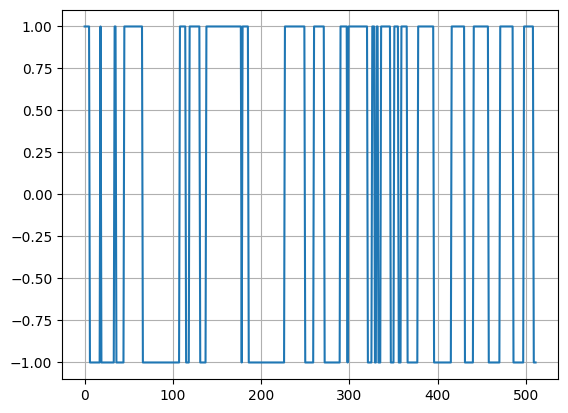

In [107]:
np_arr = img.squeeze().detach().numpy()

   
for row_index in [30, 100, 150, 450, 400]:
    plt.figure()
    # Plot the magnitude spectrum
    plt.plot(np_arr[row_index, :])
    plt.grid(True)
    plt.show()

In [ ]:
def wavelet_transformation(particle):
    pass


def distance_in_latent_space(particle):
    scale_distance_in_time = 0 
    distance_in_decomposed_space = 0
    return scale_distance_in_time + distance_in_decomposed_space

[0.70710678]


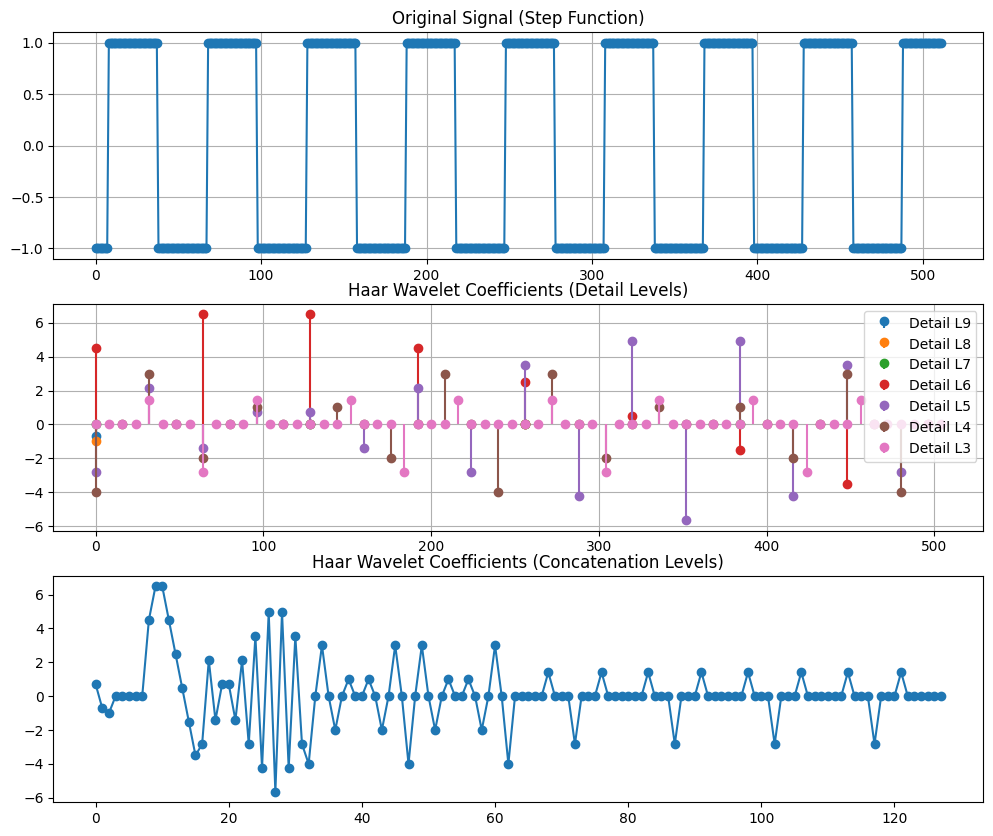

In [121]:
import numpy as np
import matplotlib.pyplot as plt

def haar_transform(signal):
    coeffs = []
    s = signal.copy()
    N = len(s)
    while N > 1:
        avg = (s[0:N:2] + s[1:N:2]) / np.sqrt(2)
        diff = (s[0:N:2] - s[1:N:2]) / np.sqrt(2)
        coeffs.append(diff)
        s = avg
        N = len(s)
    coeffs.append(s)
    return coeffs[::-1]  # [approximation, detail_1, detail_2, ...]

def haar_inverse_transform(coeffs):
    """Inverse Haar transform given full coefficient list"""
    s = coeffs[0]
    for detail in coeffs[1:]:
        N = len(detail)
        up = np.zeros(2 * N)
        up[0::2] = (s + detail) / np.sqrt(2)
        up[1::2] = (s - detail) / np.sqrt(2)
        s = up
    return s

# Step signal
np_arr = img.squeeze().detach().numpy()
x = np_arr[30]
coeffs = haar_transform(x)
print(coeffs[0])
# Plot original signal
plt.figure(figsize=(12, 10))
plt.subplot(3, 1, 1)
plt.plot(x, marker='o')
plt.title("Original Signal (Step Function)")
plt.grid(True)

# Plot wavelet coefficients at each level
plt.subplot(3, 1, 2)
offset = 0
for i, c in enumerate(coeffs[1:]):  # skip approximation
    if i >= 7:
        continue
    n = len(c)
    x_vals = np.linspace(0, len(x), 2 * n, endpoint=False)[::2]
    plt.stem(x_vals, c, linefmt=f"C{i}-", markerfmt=f"C{i}o", basefmt=" ", label=f"Detail L{len(coeffs)-1-i}")
plt.title("Haar Wavelet Coefficients (Detail Levels)")
plt.legend()
plt.grid(True)

plt.subplot(3,1,3)
plt.plot(np.concatenate(coeffs[:-2]), marker='o')
plt.title("Haar Wavelet Coefficients (Concatenation Levels)")

plt.show()

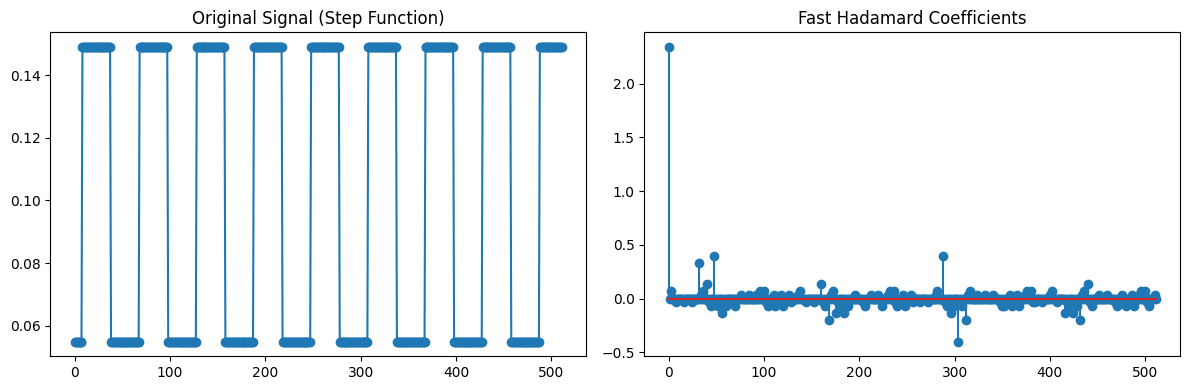

In [61]:
import numpy as np
import matplotlib.pyplot as plt

def fast_hadamard_transform(x):
    """
    Fast Hadamard Transform (in-place) for 1D signal x.
    Length of x must be a power of 2.
    """
    x = x.copy().astype(float)
    n = len(x)
    assert (n & (n - 1)) == 0, "Length must be power of 2"
    
    h = 1
    while h < n:
        for i in range(0, n, h * 2):
            for j in range(i, i + h):
                a = x[j]
                b = x[j + h]
                x[j] = (a + b) / np.sqrt(2)
                x[j + h] = (a - b) / np.sqrt(2)
        h *= 2
    return x

def inverse_fast_hadamard_transform(y):
    # Hadamard is self-inverse
    return fast_hadamard_transform(y)

# Sample step function signal
np_arr = img.squeeze().detach().numpy()
x = np_arr[30]

# Apply FHT
y = fast_hadamard_transform(x)

# Plot original and coefficients
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(x, marker='o')
plt.title("Original Signal (Step Function)")
plt.subplot(1, 2, 2)
plt.stem(y)
plt.title("Fast Hadamard Coefficients")
plt.tight_layout()
plt.show()

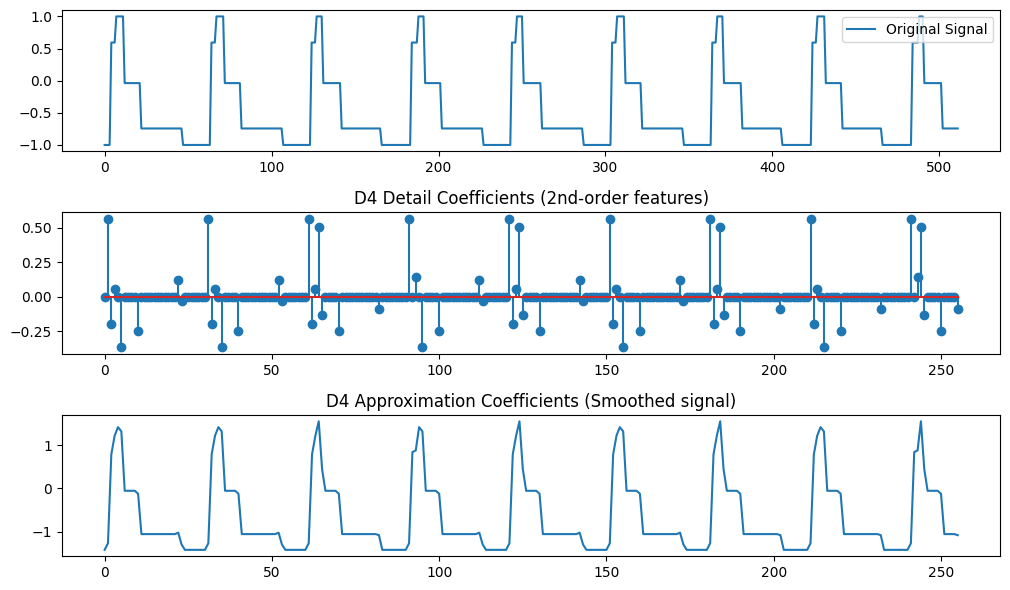

In [100]:
import matplotlib.pyplot as plt
import numpy as np

# D4 low-pass decomposition filter (scaling filter)
h = np.array([
    (1 + np.sqrt(3)) / (4 * np.sqrt(2)),
    (3 + np.sqrt(3)) / (4 * np.sqrt(2)),
    (3 - np.sqrt(3)) / (4 * np.sqrt(2)),
    (1 - np.sqrt(3)) / (4 * np.sqrt(2))
])

# D4 high-pass decomposition filter (wavelet filter)
g = np.array([
    h[3], -h[2], h[1], -h[0]
])

def dwt_d4(signal):
    N = len(signal)
    assert N % 2 == 0, "Signal length must be even for 1-level DWT"
    
    # Pad signal (wrap padding for simplicity)
    padded = np.concatenate([signal[-2:], signal, signal[:2]])
    
    approx = []
    detail = []
    for i in range(0, N, 2):
        idx = i + 2  # offset due to padding
        a = np.sum(h * padded[idx:idx+4])
        d = np.sum(g * padded[idx:idx+4])
        approx.append(a)
        detail.append(d)
    
    return np.array(approx), np.array(detail)
def idwt_d4(approx, detail):
    N = len(approx)
    rec = np.zeros(2 * N)
    for i in range(N):
        for k in range(4):
            rec[2 * i + k % 2] += approx[i] * h[k] + detail[i] * g[k]
    return rec

# Create a signal with curvature (parabola + sharp edges)
np_arr = img.squeeze().detach().numpy()
x = np_arr[30]

# Apply D4 wavelet
approx, detail = dwt_d4(x)

# Plot
plt.figure(figsize=(10, 6))
plt.subplot(3,1,1)
plt.plot(x, label="Original Signal")
plt.legend()

plt.subplot(3,1,2)
plt.stem(detail)
plt.title("D4 Detail Coefficients (2nd-order features)")
plt.subplot(3,1,3)
plt.plot(approx)
plt.title("D4 Approximation Coefficients (Smoothed signal)")
plt.tight_layout()
plt.show()